In [28]:
import warnings
warnings.filterwarnings("ignore")

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.internal_coordinates import Coordinates_mapping

from flonacomldft.collective_variables import get_CVs

In [20]:
# BERENDSEN MD DATA - MLP Models

mlps = [load_pickle_file("database/models/is{:d}_mlp_dic_training.pkl".format(mode_label)) for mode_label in [0, 1]]

zmats_train = [torch.cat([load_csv_file("database/datasets/is{:d}_{:s}_train.csv".format(mode_label, kind)).T for kind in ['flow', 'md']], dim=1).T for mode_label in [0, 1]]
zmats_test = [torch.cat([load_csv_file("database/datasets/is{:d}_{:s}_test.csv".format(mode_label, kind)).T for kind in ['flow', 'md']], dim=1).T for mode_label in [0, 1]]

In [21]:
coord_mapping = Coordinates_mapping()

xs_train = []
xs_train_logdetjacs = []
us_train = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_train[mode_label][:, :12], logdetjacs=zmats_train[mode_label][:, 14], energies=zmats_train[mode_label][:, 12], isomer=mode_label)
    xs_train.append(xs)
    xs_train_logdetjacs.append(logdetjacs)
    us_train.append(us)

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

In [22]:
xs_test = []
xs_test_logdetjacs = []
us_test = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_test[mode_label][:, :12], logdetjacs=zmats_test[mode_label][:, 14], energies=zmats_test[mode_label][:, 12], isomer=mode_label)
    xs_test.append(xs)
    xs_test_logdetjacs.append(logdetjacs)
    us_test.append(us)

In [23]:
u_target_train = torch.stack(us_train).detach().numpy()
u_predict_train = [mlps[mode_label]['model'](xs_train[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target_test = torch.stack(us_test).detach().numpy()
u_predict_test = [mlps[mode_label]['model'](xs_test[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target = {'train': u_target_train, 'test': u_target_test}
u_predict = {'train': u_predict_train, 'test': u_predict_test}

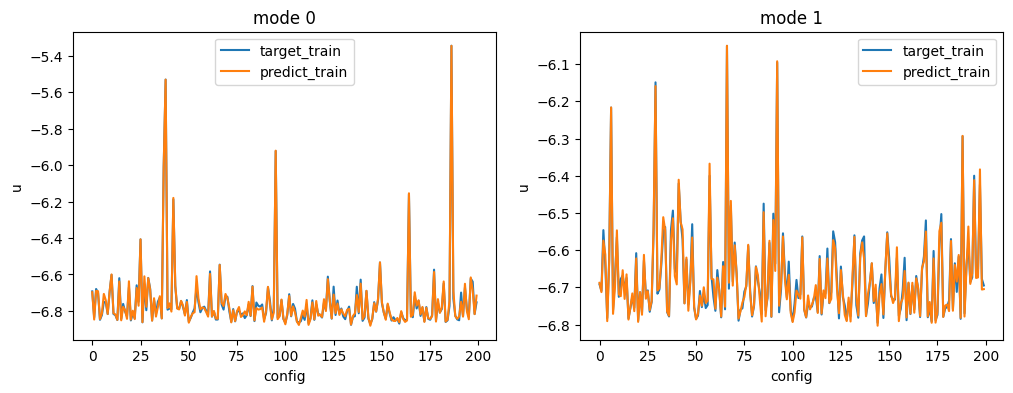

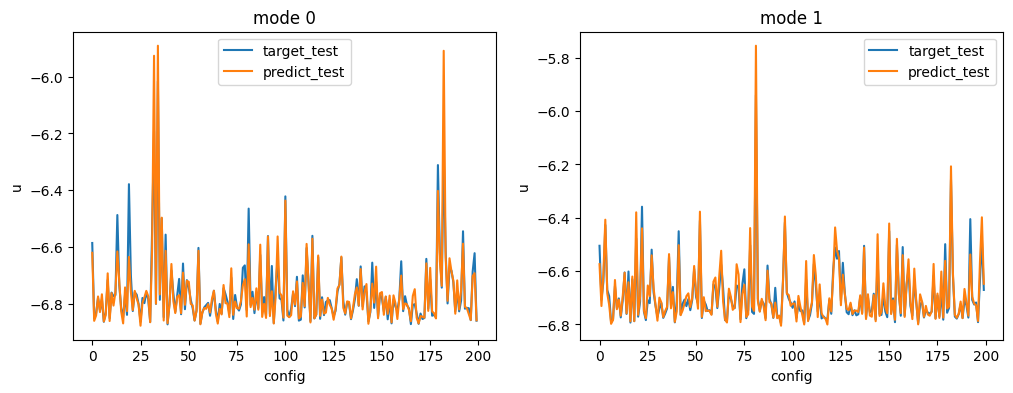

In [24]:
for datatype in ['train', 'test']:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    for mode_label in [0, 1]:
        axs[mode_label].plot(u_target[datatype][mode_label].flatten()[:200], label = 'target_{:s}'.format(datatype))
        axs[mode_label].plot(u_predict[datatype][mode_label].flatten()[:200], label = 'predict_{:s}'.format(datatype))
        axs[mode_label].set_ylabel('u')
        axs[mode_label].set_xlabel('config')
        axs[mode_label].legend()
        axs[mode_label].set_title('mode {:d}'.format(mode_label))

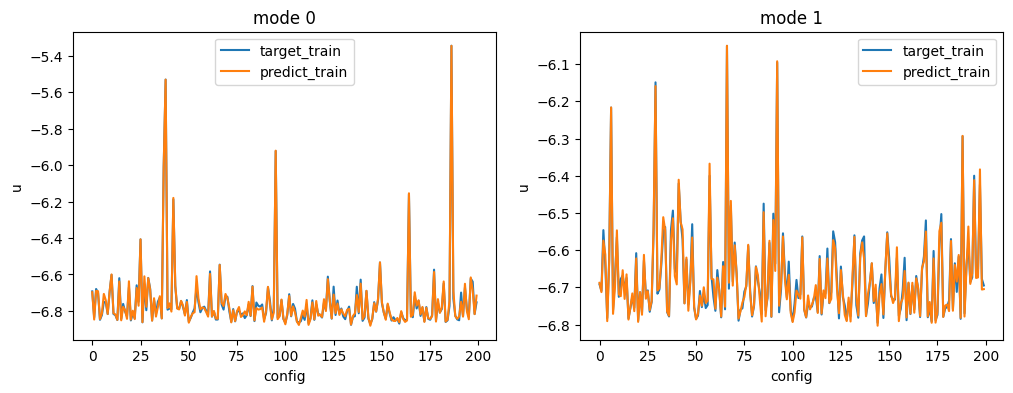

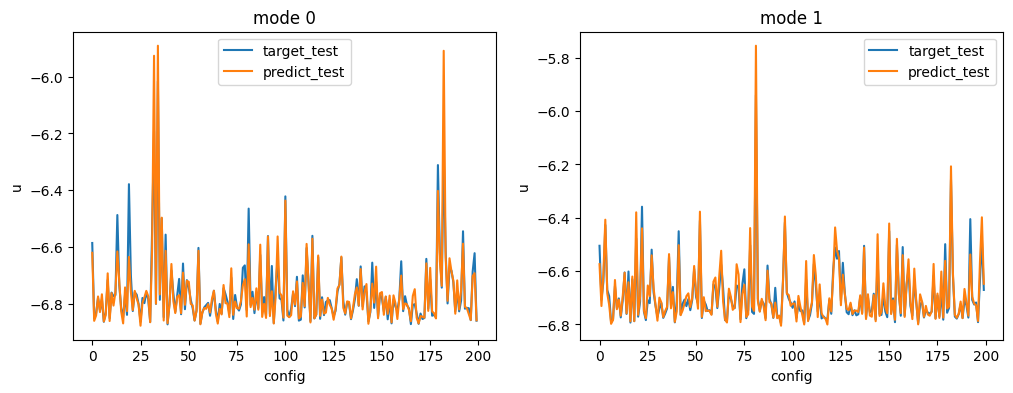

In [25]:
for datatype in ['train', 'test']:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    for mode_label in [0, 1]:
        axs[mode_label].plot(u_target[datatype][mode_label].flatten()[:200], label = 'target_{:s}'.format(datatype))
        axs[mode_label].plot(u_predict[datatype][mode_label].flatten()[:200], label = 'predict_{:s}'.format(datatype))
        axs[mode_label].set_ylabel('u')
        axs[mode_label].set_xlabel('config')
        axs[mode_label].legend()
        axs[mode_label].set_title('mode {:d}'.format(mode_label))

In [31]:
mlps = [load_pickle_file("database/andersen/is{:d}_mlp_dic_training_{:d}.pkl".format(mode_label, id)) for mode_label, id in zip([0, 1], [139859135667952, 139665637740016])]

In [33]:
zmats_train = [load_csv_file("database/andersen/is{:d}_md_train_{:d}.csv".format(mode_label, kind)) for kind, mode_label in zip([2206336, 2207841], [0, 1])]
zmats_test = [load_csv_file("database/andersen/is{:d}_md_test_{:d}.csv".format(mode_label, kind)) for kind, mode_label in zip([2206336, 2207841], [0, 1])]

In [34]:
coord_mapping = Coordinates_mapping()

xs_train = []
xs_train_logdetjacs = []
us_train = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_train[mode_label][:, :12], logdetjacs=zmats_train[mode_label][:, 14], energies=zmats_train[mode_label][:, 12], isomer=mode_label)
    xs_train.append(xs)
    xs_train_logdetjacs.append(logdetjacs)
    us_train.append(us)

xs_test = []
xs_test_logdetjacs = []
us_test = []

for mode_label in [0, 1]:
    xs, logdetjacs, us = coord_mapping.get_real_centered_from_internal(zmats_test[mode_label][:, :12], logdetjacs=zmats_test[mode_label][:, 14], energies=zmats_test[mode_label][:, 12], isomer=mode_label)
    xs_test.append(xs)
    xs_test_logdetjacs.append(logdetjacs)
    us_test.append(us)

u_target_train = torch.stack(us_train).detach().numpy()
u_predict_train = [mlps[mode_label]['model'](xs_train[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target_test = torch.stack(us_test).detach().numpy()
u_predict_test = [mlps[mode_label]['model'](xs_test[mode_label]).T.detach().numpy() for mode_label in [0, 1]]

u_target = {'train': u_target_train, 'test': u_target_test}
u_predict = {'train': u_predict_train, 'test': u_predict_test}

/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/home/ana/anaconda3/envs/ml-dft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an ind

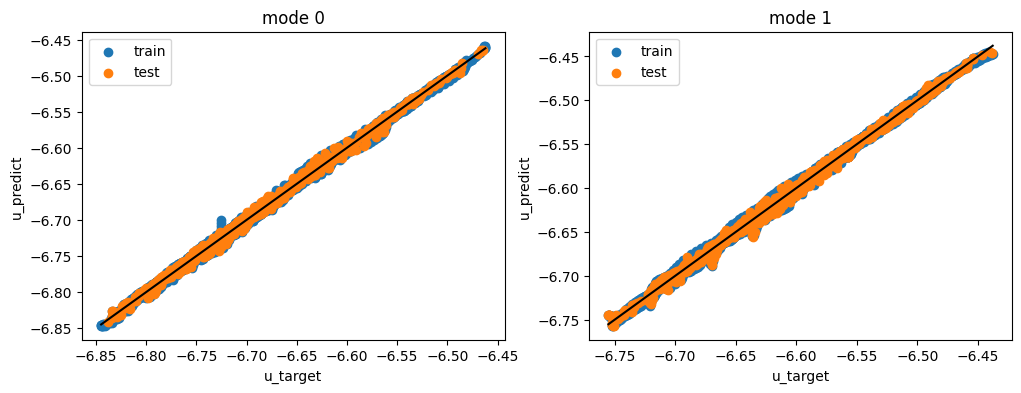

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for mode_label in [0, 1]:
    axs[mode_label].scatter(u_target['train'][mode_label].flatten(), u_predict['train'][mode_label].flatten(), label='train')
    axs[mode_label].scatter(u_target['test'][mode_label].flatten(), u_predict['test'][mode_label].flatten(), label='test')
    min_ = np.min(u_target['train'][mode_label].flatten())
    max_ = np.max(u_target['train'][mode_label].flatten())
    range_ = np.linspace(min_, max_, 2)
    axs[mode_label].plot(range_, range_, color='k')
    axs[mode_label].set_ylabel('u_predict')
    axs[mode_label].set_xlabel('u_target')
    axs[mode_label].legend()
    axs[mode_label].set_title('mode {:d}'.format(mode_label))

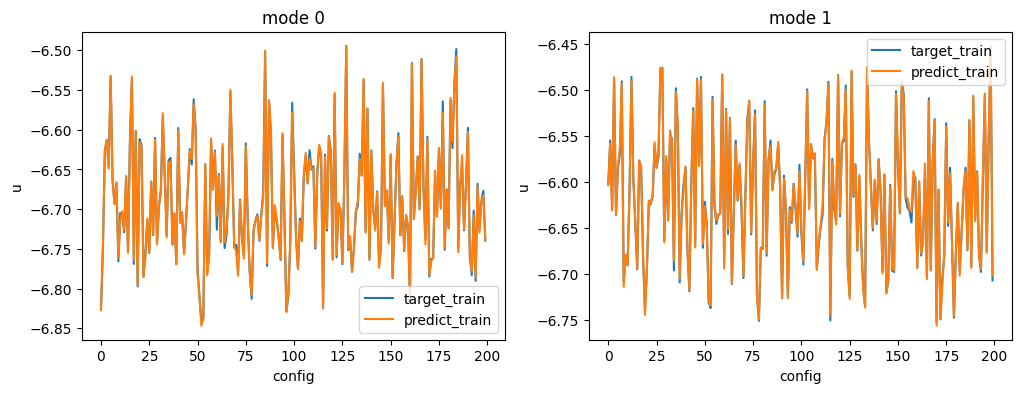

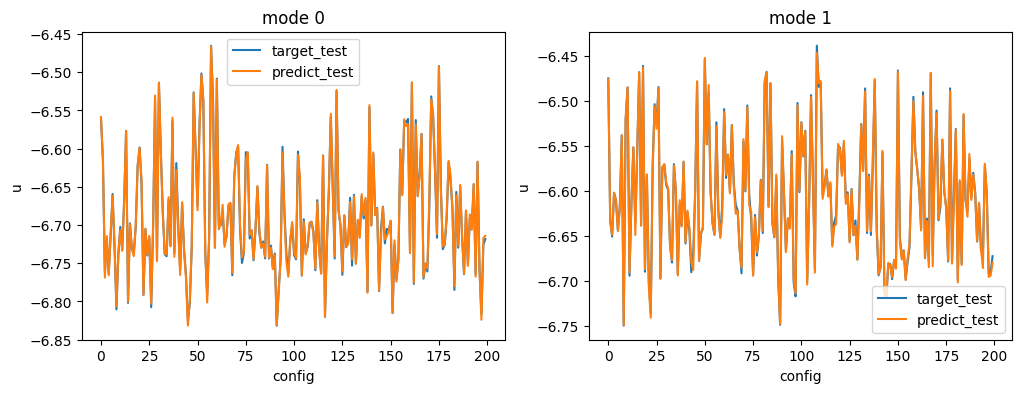

In [36]:
for datatype in ['train', 'test']:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    for mode_label in [0, 1]:
        axs[mode_label].plot(u_target[datatype][mode_label].flatten()[:200], label = 'target_{:s}'.format(datatype))
        axs[mode_label].plot(u_predict[datatype][mode_label].flatten()[:200], label = 'predict_{:s}'.format(datatype))
        axs[mode_label].set_ylabel('u')
        axs[mode_label].set_xlabel('config')
        axs[mode_label].legend()
        axs[mode_label].set_title('mode {:d}'.format(mode_label))

In [31]:
# loading andersen flows

In [36]:
flows = load_pickle_file('database/andersen/is0_flow_dic_training_6440961.pkl')

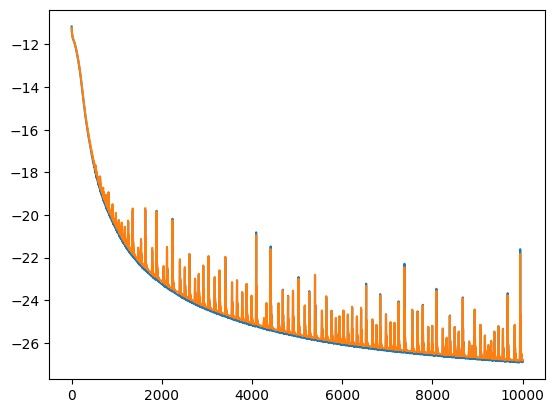

In [37]:
plt.plot(flows['losses'][0]);
plt.plot(flows['losses'][1]);

In [38]:
from flonacomldft.utils.plots import plotting_fes_db

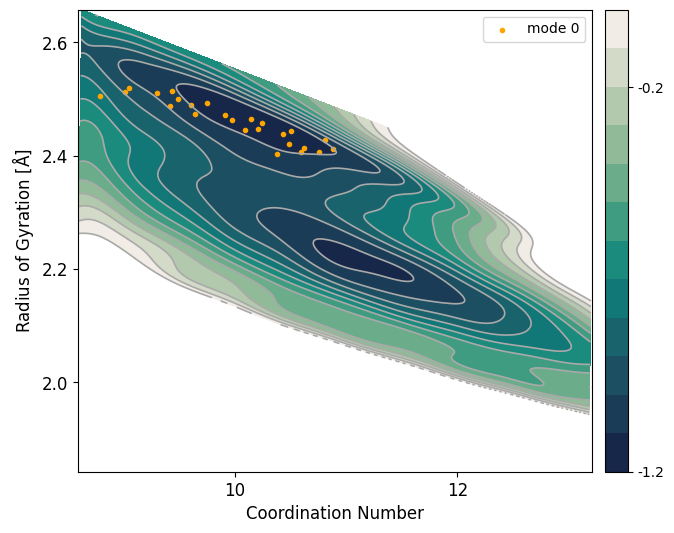

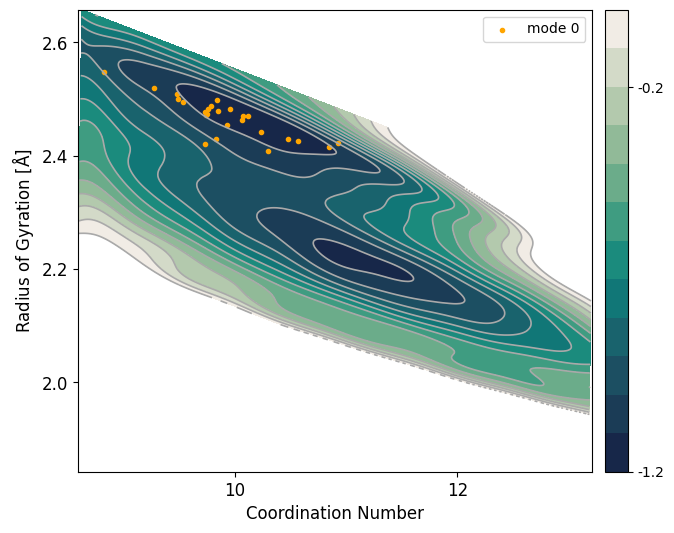

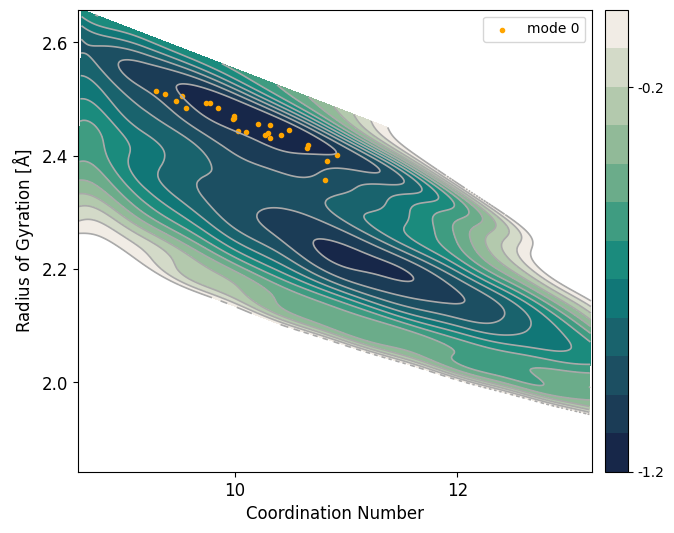

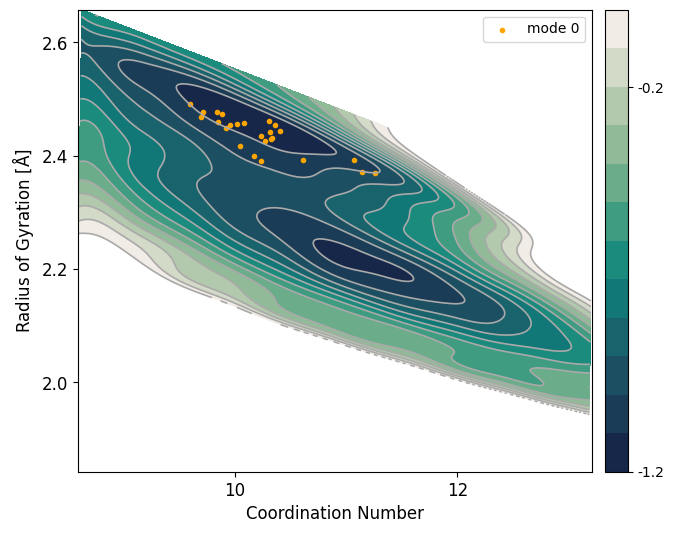

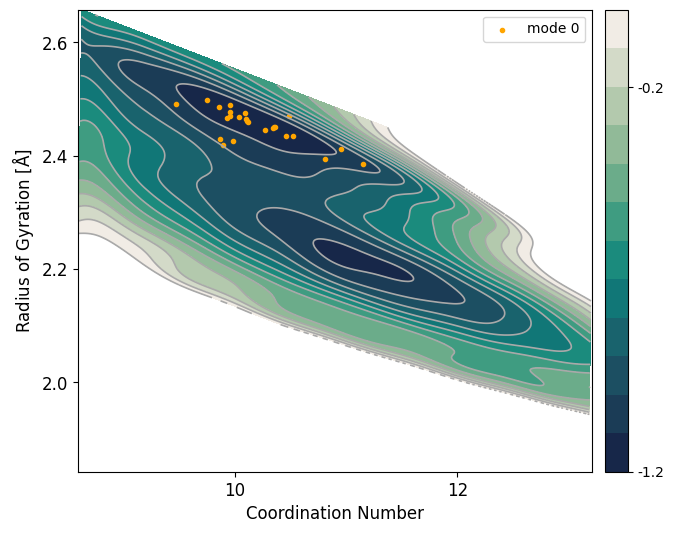

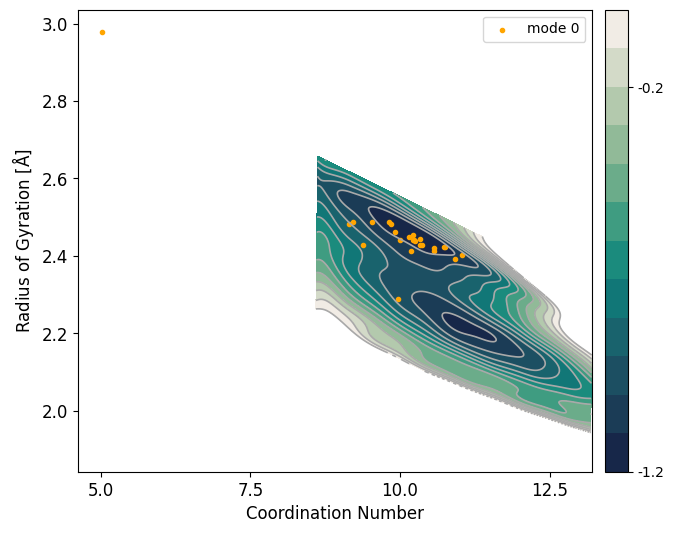

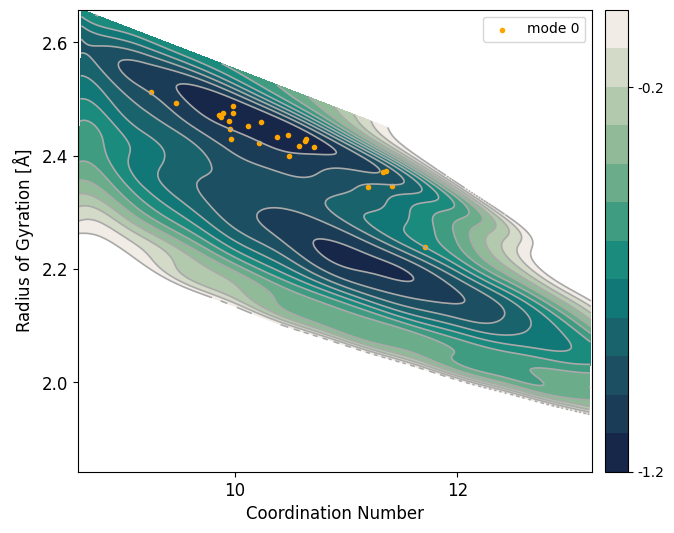

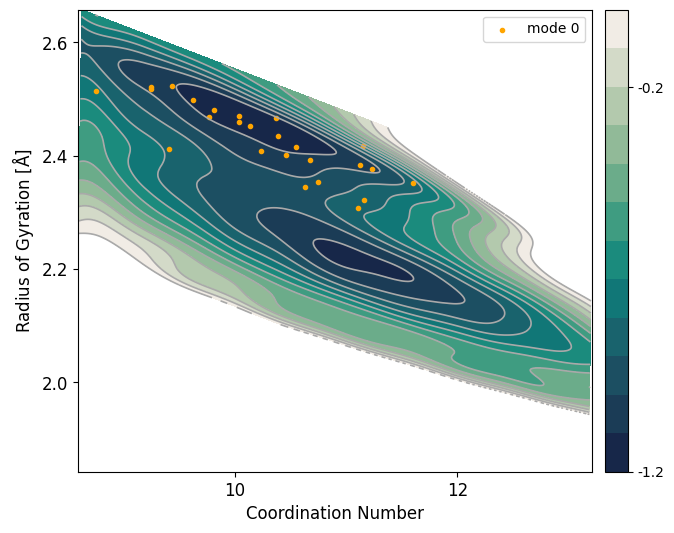

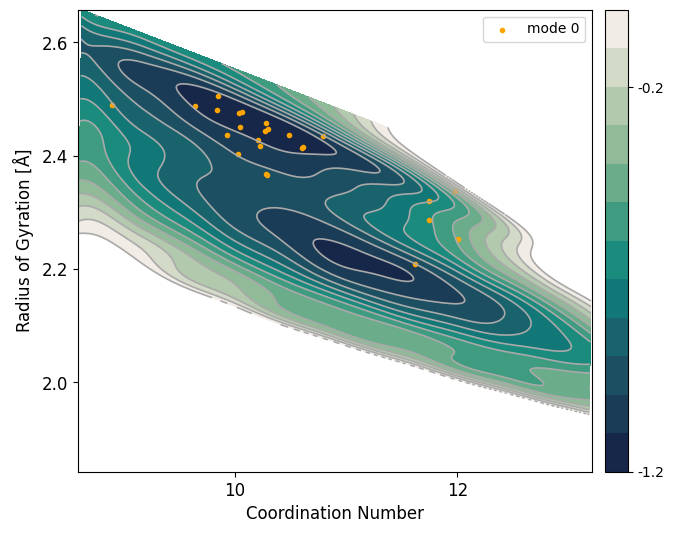

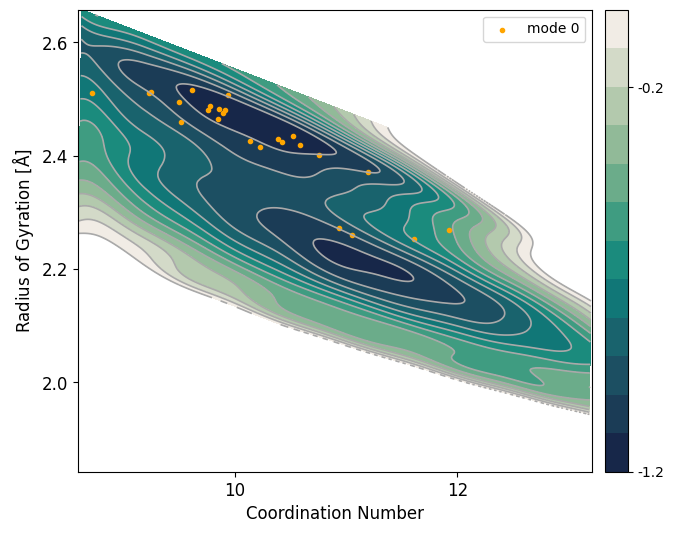

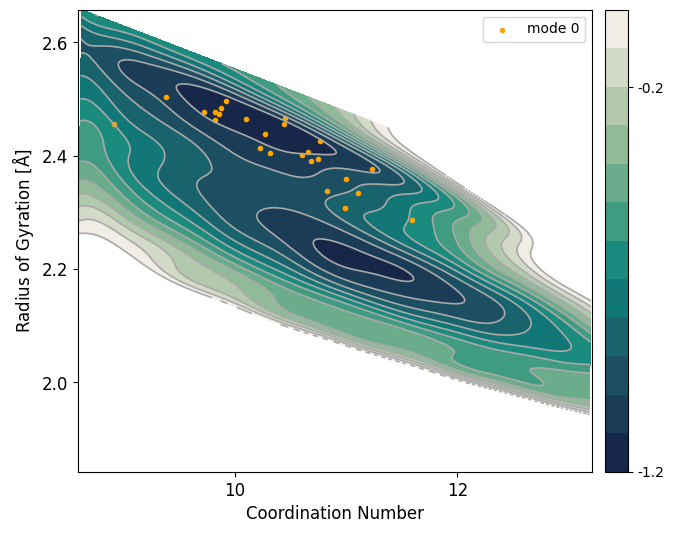

In [39]:
for model in flows['models']:
    xs = model.sample(25)
    coord_mapping = Coordinates_mapping()

    zmats, logdetjacs = coord_mapping.get_internal_from_real_centered(xs, isomer=0)
    cvs = get_CVs(zmats[:, :12])

    fig, ax = plotting_fes_db()
    ax.scatter(np.array(cvs[0]), np.array(cvs[1]), marker='.', c='orange', label='mode 0');
    plt.legend()
    fig.set_size_inches(8, 6)
    size = 12
    ax.xaxis.label.set_size(size)
    ax.yaxis.label.set_size(size)
    plt.xticks(fontsize=size)
    plt.yticks(fontsize=size);

In [43]:
sample  = flows['model'].sample(1)

from flonacomldft.dft_calculator import DFTCalculator

molecule, logdetjac = coord_mapping.build_molecule_from_real_centered(sample, isomer=0)

calculator = DFTCalculator()
calculator.initialize_calculator()

u_ = calculator.calculate_potential_energy(
    molecule, 
    filename='ag6.out'
)

u = coord_mapping.compute_energy_in_new_frame(u_, logdetjac*(-1))

In [50]:
mlp = load_pickle_file('database/andersen/is0_mlp_dic_training_3879956.pkl')
u_mlp = mlp['model'](sample)

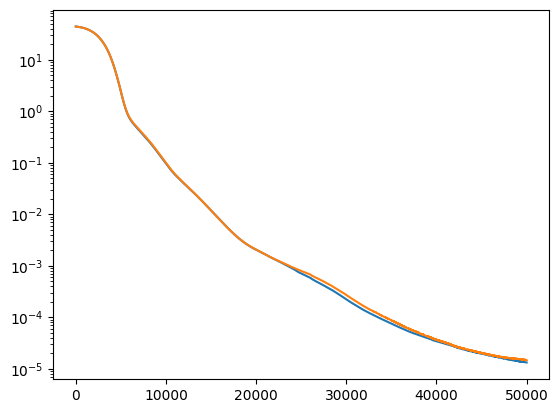

In [53]:
plt.plot(mlp['losses'][0])
plt.plot(mlp['losses'][1])
plt.yscale('log')

In [51]:
u, u_, u_mlp

(tensor([-6.6126], grad_fn=<RsubBackward1>),
 -6.361876741640033,
 tensor([[-6.6905]], grad_fn=<AddmmBackward0>))

<AxesSubplot:>

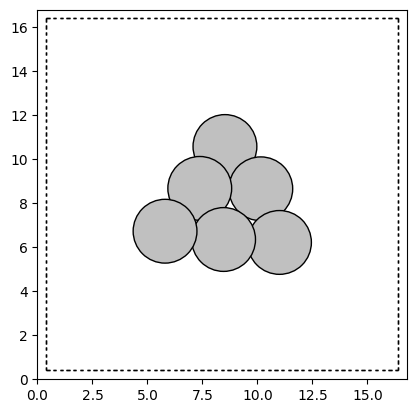

In [47]:
from ase.visualize.plot import plot_atoms

plot_atoms(molecule)

In [48]:
from ase.visualize import view
view(molecule)

<Popen: returncode: None args: ['/home/ana/anaconda3/envs/ml-dft/bin/python'...>